In [325]:
import torch
from torch.distributions.multivariate_normal import MultivariateNormal as MVN
import matplotlib.pyplot as plt

In [326]:
class MultivariateNormal:
    def __init__(self, n_features, mus, covariances, scale_factors):
        if n_features < 2:
            raise ValueError('The number of features must be greater than 1.')
        
        if len(mus) != len(covariances):
            raise ValueError('The number of means and covariances must be the same.')        
        
        if len(mus) != len(scale_factors):
            raise ValueError('The number of means and scale_factors must be the same.')
        
        self.n_features = n_features
        self.mu = mus
        self.covariances = covariances
        self.scale_factors = scale_factors
        self.mvns = []
        
        for i in range(len(mus)):
            mu = mus[i]
            covariance = covariances[i]
            
            if mu.shape[0] != n_features:
                raise ValueError('The number of features of every mu must be the same as n_features.')
            
            self.mvns.append(MVN(mu, covariance))

        
    def sample(self, sample_points):
        pdf = torch.zeros(sample_points.shape[0])
        
        for i in range(len(self.mvns)):
            mvn = self.mvns[i]
            scale_factor = self.scale_factors[i]
            pdf += scale_factor * torch.exp(mvn.log_prob(sample_points))
        
        return pdf
    
    
    def plot(self):
        n_plots = 4
        n_samples = 100
        plot_elevs = [30, 60, 90, 30]
        plot_azims = [30, 60, 90, 120]
        
        samples = torch.tensor([])
        
        fig = plt.figure(figsize=(12, 8))
        
        for i in range(self.n_features):
            feature = torch.linspace(-7, 7, n_samples)
            samples = torch.cat([samples, feature.unsqueeze(1)], dim=1)
            
        X, Y = torch.meshgrid(samples[:, 0], samples[:, 1])
        
        xy_grid = torch.stack([X.ravel(), Y.ravel()], dim=1)
        
        pdf_values = self.sample(xy_grid).reshape(n_samples, n_samples)
                    
        for i in range(n_plots):
            ax = fig.add_subplot(2, 2, i+1, projection='3d')
            ax.plot_surface(X.numpy(), Y.numpy(), pdf_values.numpy(), cmap='viridis')
            ax.view_init(elev=plot_elevs[i], azim=plot_azims[i])

        # Show the plot
        plt.tight_layout()
        plt.show()
        
    
    def pca(self, X):
        mean = torch.mean(X, dim=0)
        std = torch.std(X, dim=0)

        # Standardize the data
        X_std = (X - mean) / std

        # Step 2 & 3: Compute SVD
        U, S, V = torch.pca_lowrank(X_std)

        # Step 4: Select the number of principal components
        n_components = 2  # For example, reduce to 2 dimensions
        U = U[:, :n_components]

        # Step 5: Project data onto lower-dimensional space
        X_reduced = torch.mm(U, torch.diag(S[:n_components]))
        
        return X_reduced

In [327]:
mu_1 = torch.tensor([0.0, 0.0])
mu_2 = torch.tensor([3.0, 3.0])
mu_3 = torch.tensor([-3.0, 3.0])
mu_4 = torch.tensor([-3.0, -3.0])
mu_5 = torch.tensor([3.0, -3.0])

sigma_1 = torch.eye(2)
sigma_2 = torch.eye(2)
sigma_3 = torch.eye(2)
sigma_4 = torch.eye(2)
sigma_5 = torch.eye(2)

means = [mu_1, mu_2, mu_3, mu_4, mu_5]
covariances = [sigma_1, sigma_2, sigma_3, sigma_4, sigma_5]
scale_factors = [1.0, 0.5, 1.25, 2, 1.0]

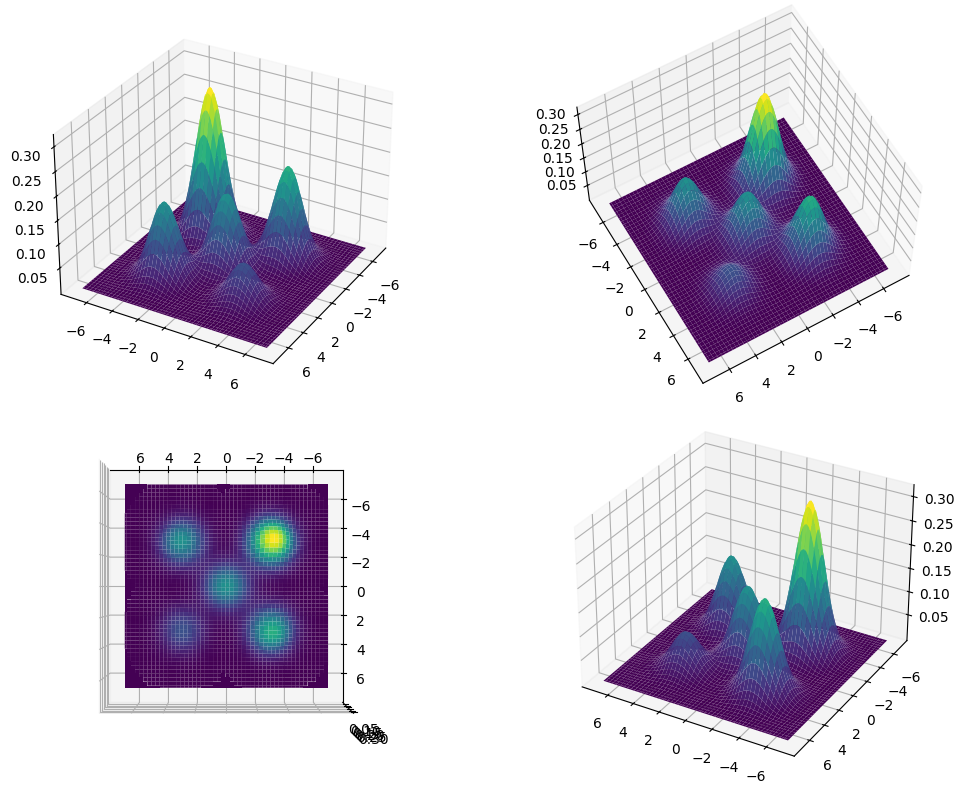

In [328]:
mvn_1 = MultivariateNormal(2, means, covariances, scale_factors)
mvn_1.plot()

In [329]:
mu_1 = torch.tensor([0.0, 0.0, 0.0, 0.0])
mu_2 = torch.tensor([3.0, 3.0, 3.0, 3.0])
mu_3 = torch.tensor([-3.0, 3.0, 3.0, -3.0])
mu_4 = torch.tensor([-3.0, -3.0, 3.0, 3.0])
mu_5 = torch.tensor([3.0, -3.0, 3.0, -3.0])

sigma_1 = torch.eye(4)
sigma_2 = torch.eye(4)
sigma_3 = torch.eye(4)
sigma_4 = torch.eye(4)
sigma_5 = torch.eye(4)

means = [mu_1, mu_2, mu_3, mu_4, mu_5]
covariances = [sigma_1, sigma_2, sigma_3, sigma_4, sigma_5]
scale_factors = [1.0, 0.5, 1.25, 2, 1.0]

In [330]:
mvn_2 = MultivariateNormal(4, means, covariances, scale_factors)
mvn_2.plot()

ValueError: The right-most size of value must match event_shape: torch.Size([10000, 2]) vs torch.Size([4]).

<Figure size 1200x800 with 0 Axes>

In [ ]:
# A = torch.tensor([[1, 0.5], [0.5, 1]])
# A = A @ A.mT
# Ap = torch.matmul(A, A.mT)

# display(A)
# display(Ap)